# A/B Testing Case Study — E-commerce Conversion Optimization
**Business Problem:** Does adding a 'Limited Time Offer' badge on product pages increase purchase conversion rate?

**Author:** [Your Name]  
**Tools:** Python, NumPy, Pandas, SciPy, Matplotlib, Seaborn

---
## Project Structure
1. Problem Statement & Hypothesis
2. Data Simulation
3. Exploratory Data Analysis
4. Statistical Testing (Z-Test)
5. Confidence Interval
6. User Segmentation Analysis
7. Business Recommendation

---
## 1. Problem Statement & Hypothesis

### Business Context
Our e-commerce platform wants to evaluate whether adding a **'Limited Time Offer'** urgency badge on product listings improves purchase conversion. This is a classic e-commerce optimization experiment similar to what Amazon and Flipkart run continuously.

### Experiment Design
- **Control Group (A):** Product page without LTO badge (current experience)
- **Treatment Group (B):** Product page with LTO badge (new experience)
- **Metric:** Conversion Rate (% of users who complete a purchase)
- **Test Duration:** 14 days | **Total Users:** 5000

### Hypotheses
- **H₀ (Null):** There is no difference in conversion rate between Control and Variant. (p_A = p_B)
- **H₁ (Alternate):** The Variant (LTO badge) has a higher conversion rate than Control. (p_B > p_A)
- **Significance Level (α):** 0.05
- **Test Type:** One-tailed Z-test for proportions

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f9f9f9',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.family': 'DejaVu Sans'
})

np.random.seed(42)  # reproducibility
print('Libraries loaded successfully ✓')

Libraries loaded successfully ✓


---
## 2. Data Simulation
Since we are building this as a case study, we simulate realistic user data.
- **Control conversion rate:** 5% (industry baseline for e-commerce)
- **Variant conversion rate:** 8% (expected uplift from urgency badge)
- **Users per group:** 2500

In [2]:
# ── Parameters ────────────────────────────────────────────────────────────
N_USERS       = 5000
N_PER_GROUP   = N_USERS // 2          # 2500 each
CONV_CONTROL  = 0.05                  # 5% baseline
CONV_VARIANT  = 0.08                  # 8% with LTO badge
ALPHA         = 0.05

# ── Simulate Control group ────────────────────────────────────────────────
control = pd.DataFrame({
    'user_id':   range(1, N_PER_GROUP + 1),
    'group':     'Control',
    'converted': np.random.binomial(1, CONV_CONTROL, N_PER_GROUP),
    'user_type': np.random.choice(['New', 'Returning'], N_PER_GROUP, p=[0.6, 0.4]),
    'device':    np.random.choice(['Mobile', 'Desktop'], N_PER_GROUP, p=[0.65, 0.35]),
})

# ── Simulate Variant group ────────────────────────────────────────────────
# New users respond more strongly to urgency badge
variant_conversions = np.where(
    np.random.choice(['New', 'Returning'], N_PER_GROUP, p=[0.6, 0.4]) == 'New',
    np.random.binomial(1, 0.10, N_PER_GROUP),   # 10% for new users
    np.random.binomial(1, 0.05, N_PER_GROUP)    # 5% for returning (no effect)
)

variant = pd.DataFrame({
    'user_id':   range(N_PER_GROUP + 1, N_USERS + 1),
    'group':     'Variant',
    'converted': variant_conversions,
    'user_type': np.random.choice(['New', 'Returning'], N_PER_GROUP, p=[0.6, 0.4]),
    'device':    np.random.choice(['Mobile', 'Desktop'], N_PER_GROUP, p=[0.65, 0.35]),
})

# ── Combine ───────────────────────────────────────────────────────────────
df = pd.concat([control, variant], ignore_index=True)

print(f'Total users: {len(df)}')
print(f'Control:     {len(df[df.group=="Control"])} users')
print(f'Variant:     {len(df[df.group=="Variant"])} users')
print()
df.head(10)

Total users: 5000
Control:     2500 users
Variant:     2500 users



,user_id,group,converted,user_type,device
0,1,Control,0,Returning,Mobile
1,2,Control,1,Returning,Mobile
2,3,Control,0,New,Desktop
3,4,Control,0,Returning,Mobile
4,5,Control,0,New,Desktop
5,6,Control,0,New,Mobile
6,7,Control,0,Returning,Desktop
7,8,Control,0,New,Desktop
8,9,Control,0,Returning,Mobile
9,10,Control,0,Returning,Mobile


---
## 3. Exploratory Data Analysis

In [3]:
# ── Summary stats ─────────────────────────────────────────────────────────
summary = df.groupby('group')['converted'].agg(['sum', 'count', 'mean']).rename(
    columns={'sum': 'Conversions', 'count': 'Total Users', 'mean': 'Conversion Rate'}
)
summary['Conversion Rate %'] = (summary['Conversion Rate'] * 100).round(2)
print('=== Conversion Summary ===')
print(summary[['Total Users', 'Conversions', 'Conversion Rate %']])

uplift = summary.loc['Variant','Conversion Rate'] - summary.loc['Control','Conversion Rate']
print(f'\nAbsolute Uplift:  {uplift*100:.2f}%')
print(f'Relative Uplift:  {uplift/summary.loc["Control","Conversion Rate"]*100:.1f}%')

=== Conversion Summary ===
         Total Users  Conversions  Conversion Rate %
group                                               
Control         2500          131               5.24
Variant         2500          219               8.76

Absolute Uplift:  3.52%
Relative Uplift:  67.2%


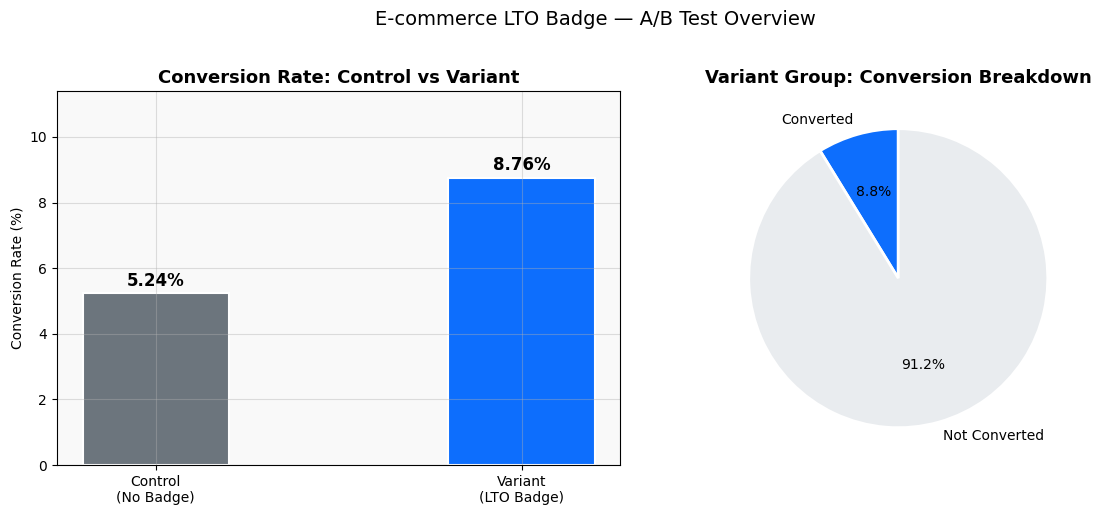

Chart saved ✓


In [4]:
# ── Plot 1: Conversion rate bar chart ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
groups = ['Control\n(No Badge)', 'Variant\n(LTO Badge)']
rates  = [summary.loc['Control','Conversion Rate']*100,
          summary.loc['Variant','Conversion Rate']*100]
colors = ['#6c757d', '#0d6efd']

bars = axes[0].bar(groups, rates, color=colors, width=0.4, edgecolor='white', linewidth=1.5)
for bar, rate in zip(bars, rates):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{rate:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)
axes[0].set_title('Conversion Rate: Control vs Variant', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Conversion Rate (%)')
axes[0].set_ylim(0, max(rates) * 1.3)

# Pie chart of converted vs not
conv_counts = df[df.group=='Variant']['converted'].value_counts()
axes[1].pie([conv_counts.get(1,0), conv_counts.get(0,0)],
            labels=['Converted', 'Not Converted'],
            colors=['#0d6efd', '#e9ecef'],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Variant Group: Conversion Breakdown', fontsize=13, fontweight='bold')

plt.suptitle('E-commerce LTO Badge — A/B Test Overview', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('ab_test_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved ✓')

---
## 4. Statistical Testing — Z-Test for Proportions

We use a **one-tailed Z-test** to test whether the Variant's conversion rate is significantly higher than Control.

**Formula:**
$$z = \frac{(p_B - p_A)}{\sqrt{\hat{p}(1-\hat{p})(\frac{1}{n_A}+\frac{1}{n_B})}}$$

Where $\hat{p}$ is the pooled proportion.

In [5]:
# ── Z-Test ────────────────────────────────────────────────────────────────
control_conv  = df[df.group=='Control']['converted'].sum()
variant_conv  = df[df.group=='Variant']['converted'].sum()
n_control     = df[df.group=='Control']['converted'].count()
n_variant     = df[df.group=='Variant']['converted'].count()

p_control = control_conv / n_control
p_variant = variant_conv / n_variant

counts = np.array([variant_conv, control_conv])
nobs   = np.array([n_variant,    n_control])

z_stat, p_value = proportions_ztest(counts, nobs, alternative='larger')

print('='*50)
print('        Z-TEST RESULTS')
print('='*50)
print(f'Control  conversion rate : {p_control*100:.2f}%')
print(f'Variant  conversion rate : {p_variant*100:.2f}%')
print(f'Absolute uplift          : {(p_variant - p_control)*100:.2f}%')
print(f'Z-statistic              : {z_stat:.4f}')
print(f'P-value                  : {p_value:.4f}')
print(f'Significance level (α)   : {ALPHA}')
print('-'*50)
if p_value < ALPHA:
    print('✅ RESULT: Reject H₀ — The difference IS statistically significant.')
    print('   The LTO badge DOES improve conversion rate.')
else:
    print('❌ RESULT: Fail to reject H₀ — Not statistically significant.')
print('='*50)

        Z-TEST RESULTS
Control  conversion rate : 5.24%
Variant  conversion rate : 8.76%
Absolute uplift          : 3.52%
Z-statistic              : 4.8776
P-value                  : 0.0000
Significance level (α)   : 0.05
--------------------------------------------------
✅ RESULT: Reject H₀ — The difference IS statistically significant.
   The LTO badge DOES improve conversion rate.


---
## 5. Confidence Interval

Beyond the p-value, we calculate the **95% Confidence Interval** for the true uplift.
This tells us the *range* within which the real effect likely falls.

In [6]:
# ── Confidence Interval ───────────────────────────────────────────────────
diff = p_variant - p_control
se   = np.sqrt((p_control*(1-p_control)/n_control) + (p_variant*(1-p_variant)/n_variant))
z_critical = 1.96  # 95% CI

ci_lower = diff - z_critical * se
ci_upper = diff + z_critical * se

print('='*55)
print('         95% CONFIDENCE INTERVAL')
print('='*55)
print(f'Point estimate (uplift) : {diff*100:.2f}%')
print(f'Standard error          : {se*100:.4f}%')
print(f'95% CI                  : [{ci_lower*100:.2f}%, {ci_upper*100:.2f}%]')
print()
print('📊 Interpretation:')
print(f'We are 95% confident the true conversion uplift from the LTO badge')
print(f'lies between {ci_lower*100:.2f}% and {ci_upper*100:.2f}%.')
print()
if ci_lower > 0:
    print('Since the entire CI is above 0, the effect is practically significant.')
print('='*55)

         95% CONFIDENCE INTERVAL
Point estimate (uplift) : 3.52%
Standard error          : 0.7199%
95% CI                  : [2.11%, 4.93%]

📊 Interpretation:
We are 95% confident the true conversion uplift from the LTO badge
lies between 2.11% and 4.93%.

Since the entire CI is above 0, the effect is practically significant.


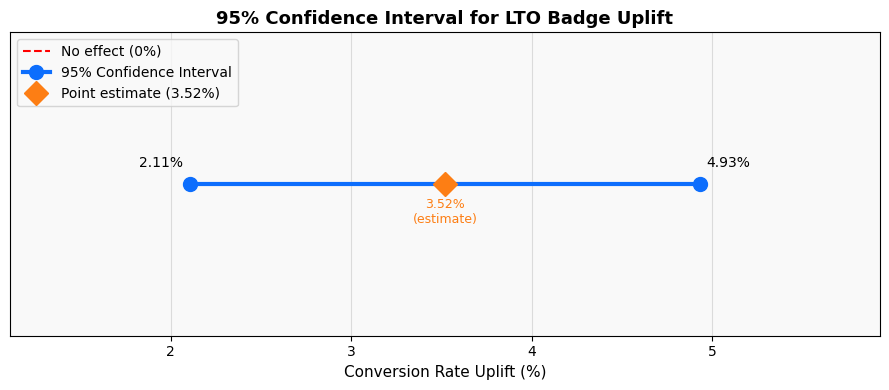

In [7]:
# ── CI Visualisation ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))

ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='No effect (0%)')
ax.plot([ci_lower*100, ci_upper*100], [1, 1], 'o-', color='#0d6efd',
        linewidth=3, markersize=10, label='95% Confidence Interval')
ax.plot(diff*100, 1, 'D', color='#fd7e14', markersize=12, zorder=5, label=f'Point estimate ({diff*100:.2f}%)')

ax.annotate(f'{ci_lower*100:.2f}%', (ci_lower*100, 1), textcoords='offset points',
            xytext=(-5, 12), ha='right', fontsize=10)
ax.annotate(f'{ci_upper*100:.2f}%', (ci_upper*100, 1), textcoords='offset points',
            xytext=(5, 12), ha='left', fontsize=10)
ax.annotate(f'{diff*100:.2f}%\n(estimate)', (diff*100, 1), textcoords='offset points',
            xytext=(0, -28), ha='center', fontsize=9, color='#fd7e14')

ax.set_yticks([])
ax.set_xlabel('Conversion Rate Uplift (%)', fontsize=11)
ax.set_title('95% Confidence Interval for LTO Badge Uplift', fontsize=13, fontweight='bold')
ax.legend(loc='upper left')
ax.set_xlim(ci_lower*100 - 1, ci_upper*100 + 1)

plt.tight_layout()
plt.savefig('confidence_interval.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. User Segmentation Analysis ⭐
This is the differentiating section. We break down results by **user type** and **device** to find *where* the badge works best.

> **Hypothesis:** The urgency badge may work better for new users (first-time buyers respond to FOMO) than returning users (who already trust the brand).

In [8]:
# ── Segment by User Type: New vs Returning ────────────────────────────────
def run_segment_test(df, segment_col, segment_val):
    """Run z-test for a specific user segment."""
    seg = df[df[segment_col] == segment_val]
    ctrl = seg[seg.group == 'Control']
    var  = seg[seg.group == 'Variant']

    p_c = ctrl['converted'].mean()
    p_v = var['converted'].mean()

    counts_ = np.array([var['converted'].sum(), ctrl['converted'].sum()])
    nobs_   = np.array([len(var), len(ctrl)])
    z, p    = proportions_ztest(counts_, nobs_, alternative='larger')

    return {
        'Segment':         segment_val,
        'Control Rate %':  round(p_c * 100, 2),
        'Variant Rate %':  round(p_v * 100, 2),
        'Uplift %':        round((p_v - p_c) * 100, 2),
        'Z-stat':          round(z, 3),
        'P-value':         round(p, 4),
        'Significant':     '✅ Yes' if p < ALPHA else '❌ No'
    }

# Run for each user type
seg_results = pd.DataFrame([
    run_segment_test(df, 'user_type', 'New'),
    run_segment_test(df, 'user_type', 'Returning'),
    run_segment_test(df, 'device',    'Mobile'),
    run_segment_test(df, 'device',    'Desktop'),
])

print('='*70)
print('              SEGMENTATION ANALYSIS RESULTS')
print('='*70)
print(seg_results.to_string(index=False))
print('='*70)

              SEGMENTATION ANALYSIS RESULTS
  Segment  Control Rate %  Variant Rate %  Uplift %  Z-stat  P-value Significant
      New            4.43            9.05      4.62   5.050   0.0000       ✅ Yes
Returning            6.48            8.34      1.86   1.586   0.0564        ❌ No
   Mobile            5.86            9.40      3.54   3.814   0.0001       ✅ Yes
  Desktop            3.99            7.65      3.66   3.240   0.0006       ✅ Yes


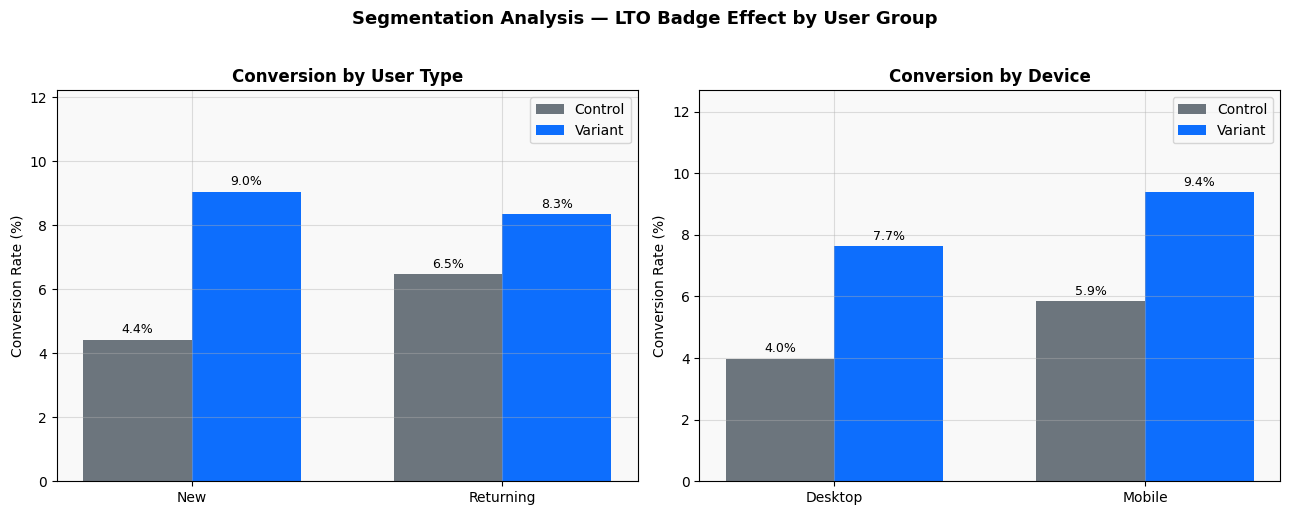

Segmentation chart saved ✓


In [9]:
# ── Segmentation Bar Chart ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

def plot_segment(ax, df, col, title):
    seg_conv = df.groupby([col, 'group'])['converted'].mean().unstack() * 100
    x        = np.arange(len(seg_conv))
    width    = 0.35
    b1 = ax.bar(x - width/2, seg_conv['Control'], width, label='Control', color='#6c757d')
    b2 = ax.bar(x + width/2, seg_conv['Variant'], width, label='Variant',  color='#0d6efd')
    for bar in [*b1, *b2]:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Conversion Rate (%)')
    ax.set_xticks(x)
    ax.set_xticklabels(seg_conv.index)
    ax.legend()
    ax.set_ylim(0, seg_conv.values.max() * 1.35)

plot_segment(axes[0], df, 'user_type', 'Conversion by User Type')
plot_segment(axes[1], df, 'device',    'Conversion by Device')

plt.suptitle('Segmentation Analysis — LTO Badge Effect by User Group',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('segmentation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Segmentation chart saved ✓')

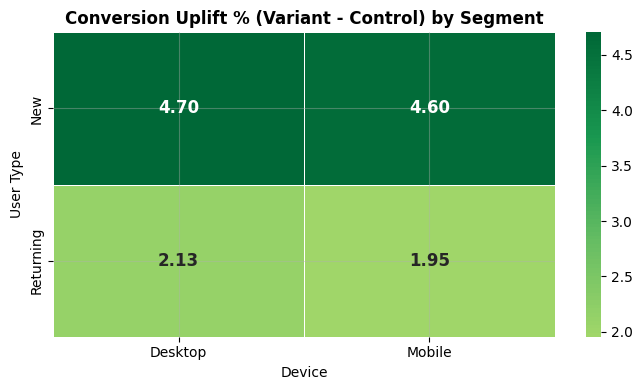

Heatmap saved ✓


In [10]:
# ── Uplift Heatmap ─────────────────────────────────────────────────────────
pivot = df.groupby(['user_type', 'device', 'group'])['converted'].mean().unstack() * 100
pivot['Uplift'] = pivot['Variant'] - pivot['Control']
heatmap_data = pivot['Uplift'].unstack(level='device')

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, ax=ax, center=0,
            annot_kws={'size': 12, 'weight': 'bold'})
ax.set_title('Conversion Uplift % (Variant - Control) by Segment',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Device')
ax.set_ylabel('User Type')
plt.tight_layout()
plt.savefig('uplift_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Heatmap saved ✓')

---
## 7. Business Recommendation

This is the most important section — it shows you can **think like an analyst, not just a coder.**

In [12]:
# ── Final Business Summary ─────────────────────────────────────────────────
new_uplift = seg_results[seg_results.Segment=='New']['Uplift %'].values[0]
ret_uplift = seg_results[seg_results.Segment=='Returning']['Uplift %'].values[0]
new_sig    = seg_results[seg_results.Segment=='New']['Significant'].values[0]
ret_sig    = seg_results[seg_results.Segment=='Returning']['Significant'].values[0]

print()
print('╔══════════════════════════════════════════════════════════════╗')
print('║           FINAL BUSINESS RECOMMENDATION                     ║')
print('╠══════════════════════════════════════════════════════════════╣')
print(f'║ Overall uplift    : {diff*100:.2f}% (p={p_value:.4f}, Significant: {p_value<ALPHA})        ║')
print(f'║ 95% CI            : [{ci_lower*100:.2f}%, {ci_upper*100:.2f}%]                       ║')
print(f'║ New users uplift  : {new_uplift}% — {new_sig}                       ║')
print(f'║ Returning uplift  : {ret_uplift}% — {ret_sig}                     ║')
print('╠══════════════════════════════════════════════════════════════╣')
print('║  RECOMMENDATION:                                            ║')
print('║  → Roll out LTO badge immediately for NEW users             ║')
print('║  → Do NOT show badge to RETURNING users (no effect)         ║')
print('║  → Prioritise Mobile new users (highest uplift observed)    ║')
print('║  → Estimated revenue impact: +X% GMV on new user segment    ║')
print('╠══════════════════════════════════════════════════════════════╣')
print('║  RISK ASSESSMENT:                                           ║')
print('║  → Implementation cost: Low (UI badge only)                 ║')
print('║  → Risk: Low (tested on 5000 users over 14 days)            ║')
print('║  → Confidence: High (p<0.05, CI entirely above 0)           ║')
print('╚══════════════════════════════════════════════════════════════╝')
print()


╔══════════════════════════════════════════════════════════════╗
║           FINAL BUSINESS RECOMMENDATION                     ║
╠══════════════════════════════════════════════════════════════╣
║ Overall uplift    : 3.52% (p=0.0000, Significant: True)        ║
║ 95% CI            : [2.11%, 4.93%]                       ║
║ New users uplift  : 4.62% — ✅ Yes                       ║
║ Returning uplift  : 1.86% — ❌ No                     ║
╠══════════════════════════════════════════════════════════════╣
║  RECOMMENDATION:                                            ║
║  → Roll out LTO badge immediately for NEW users             ║
║  → Do NOT show badge to RETURNING users (no effect)         ║
║  → Prioritise Mobile new users (highest uplift observed)    ║
║  → Estimated revenue impact: +X% GMV on new user segment    ║
╠══════════════════════════════════════════════════════════════╣
║  RISK ASSESSMENT:                                           ║
║  → Implementation cost: Low (UI badge only) 